# 05 — XGBoost LST Downscaling

## Objective

This notebook implements the XGBoost stage of the LST downscaling workflow for Lucknow.

The XGBoost regression model is trained using the same 90 m coarse-resolution LST target and the same spatially aggregated remote-sensing predictors used in the Random Forest baseline.

The trained model is then applied to the original 30 m predictor datasets to generate a 30 m XGBoost-based LST product.

### Predictors

- Green reflectance
- SWIR1 reflectance
- SWIR2 reflectance
- NDVI
- NDBI
- MNDWI

### Target

- 90 m coarse-resolution LST

### Experimental Design

The XGBoost model uses the same:

- 90 m predictor dataset
- target variable
- valid-pixel mask
- spatial block definition
- training/testing blocks
- evaluation metrics

as the Random Forest baseline.

This ensures that the two machine-learning models can be compared fairly.

### Workflow

90 m predictors + 90 m LST
        ↓
Same spatial training/testing split as RF
        ↓
XGBoost regression
        ↓
Trained model
        ↓
30 m predictors
        ↓
30 m XGBoost LST
        ↓
Evaluation and spatial analysis

In [6]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

print("Libraries imported successfully")

Libraries imported successfully


In [7]:
PROJECT_DIR = Path(r"D:\Projects\GeoAI-LST-Downscaling")

FINE_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "lucknow"
    / "fine"
)

COARSE_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "lucknow"
    / "coarse"
)

print("Fine directory:", FINE_DIR)
print("Coarse directory:", COARSE_DIR)

print("\nFine directory exists:", FINE_DIR.exists())
print("Coarse directory exists:", COARSE_DIR.exists())

Fine directory: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\fine
Coarse directory: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\coarse

Fine directory exists: True
Coarse directory exists: True


In [8]:
predictor_paths = {
    "green": FINE_DIR / "predictors" / "green_lucknow_reflectance.tif",
    "swir1": FINE_DIR / "predictors" / "swir1_lucknow_reflectance.tif",
    "swir2": FINE_DIR / "predictors" / "swir2_lucknow_reflectance.tif",
    "ndvi": FINE_DIR / "predictors" / "ndvi_lucknow.tif",
    "ndbi": FINE_DIR / "predictors" / "ndbi_lucknow.tif",
    "mndwi": FINE_DIR / "predictors" / "mndwi_lucknow.tif"
}

lst_90m_path = COARSE_DIR / "lst_90m_lucknow.tif"

for name, path in predictor_paths.items():
    print(f"{name:6}: {path.exists()} -> {path.name}")

print(
    f"{'lst_90m':6}:",
    lst_90m_path.exists(),
    "->",
    lst_90m_path.name
)

green : True -> green_lucknow_reflectance.tif
swir1 : True -> swir1_lucknow_reflectance.tif
swir2 : True -> swir2_lucknow_reflectance.tif
ndvi  : True -> ndvi_lucknow.tif
ndbi  : True -> ndbi_lucknow.tif
mndwi : True -> mndwi_lucknow.tif
lst_90m: True -> lst_90m_lucknow.tif


In [9]:
def aggregate_30m_to_90m(data, nodata=None):
    """
    Aggregate a 30 m raster to 90 m using 3x3
    valid-pixel means.
    """

    data = data[:702, :762]

    reshaped = data.reshape(234, 3, 254, 3)

    valid = np.isfinite(reshaped)

    if nodata is not None:
        valid &= reshaped != nodata

    data_clean = np.where(valid, reshaped, 0)

    value_sum = data_clean.sum(axis=(1, 3))
    valid_count = valid.sum(axis=(1, 3))

    result = np.full(
        (234, 254),
        np.nan,
        dtype=np.float32
    )

    valid_blocks = valid_count > 0

    result[valid_blocks] = (
        value_sum[valid_blocks]
        / valid_count[valid_blocks]
    )

    return result

In [10]:
predictor_nodata = {
    "green": 0,
    "swir1": 0,
    "swir2": 0,
    "ndvi": None,
    "ndbi": None,
    "mndwi": None
}

In [11]:
predictors_90m = {}

for name, path in predictor_paths.items():

    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)

    predictors_90m[name] = aggregate_30m_to_90m(
        data,
        nodata=predictor_nodata[name]
    )

    print(
        f"{name.upper():6} | "
        f"shape = {predictors_90m[name].shape} | "
        f"min = {np.nanmin(predictors_90m[name]):.6f} | "
        f"max = {np.nanmax(predictors_90m[name]):.6f} | "
        f"mean = {np.nanmean(predictors_90m[name]):.6f}"
    )

GREEN  | shape = (234, 254) | min = 9628.222656 | max = 17696.111328 | mean = 11892.142578
SWIR1  | shape = (234, 254) | min = 9818.888672 | max = 28746.445312 | mean = 15949.316406
SWIR2  | shape = (234, 254) | min = 8984.111328 | max = 27468.888672 | mean = 13793.961914
NDVI   | shape = (234, 254) | min = 0.102692 | max = 0.741849 | mean = 0.308028
NDBI   | shape = (234, 254) | min = -0.460101 | max = -0.009748 | mean = -0.222936
MNDWI  | shape = (234, 254) | min = -0.245560 | max = 0.051391 | mean = -0.144368


In [12]:
with rasterio.open(lst_90m_path) as src:
    lst_90m = src.read(1).astype(np.float32)

print("LST shape:", lst_90m.shape)
print("LST minimum:", np.nanmin(lst_90m))
print("LST maximum:", np.nanmax(lst_90m))

LST shape: (234, 254)
LST minimum: -9999.0
LST maximum: 44.784115


In [13]:
common_mask = (
    np.isfinite(lst_90m)
    & (lst_90m != -9999)
)

for name, data in predictors_90m.items():
    common_mask &= np.isfinite(data)

print("Valid ML pixels:", common_mask.sum())

Valid ML pixels: 35383


In [14]:
feature_names = [
    "green",
    "swir1",
    "swir2",
    "ndvi",
    "ndbi",
    "mndwi"
]

X = np.column_stack([
    predictors_90m[name][common_mask]
    for name in feature_names
])

y = lst_90m[common_mask]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35383, 6)
y shape: (35383,)


In [15]:
rows, cols = np.where(common_mask)

BLOCK_SIZE = 30

block_rows = rows // BLOCK_SIZE
block_cols = cols // BLOCK_SIZE

block_ids = (
    block_rows * (254 // BLOCK_SIZE + 1)
    + block_cols
)

print(
    "Number of unique spatial blocks:",
    np.unique(block_ids).size
)

Number of unique spatial blocks: 55


In [16]:
block_counts = (
    pd.Series(block_ids)
    .value_counts()
    .sort_index()
)

eligible_test_blocks = block_counts[
    block_counts >= 100
].index.to_numpy()

rng = np.random.default_rng(42)

test_blocks = rng.choice(
    eligible_test_blocks,
    size=11,
    replace=False
)

train_blocks = np.array([
    block
    for block in block_counts.index
    if block not in test_blocks
])

print("Training blocks:", len(train_blocks))
print("Testing blocks:", len(test_blocks))

print("\nTest block IDs:")
print(np.sort(test_blocks))

Training blocks: 44
Testing blocks: 11

Test block IDs:
[ 5  6 13 23 31 32 37 39 48 56 58]


In [17]:
train_mask = np.isin(block_ids, train_blocks)
test_mask = np.isin(block_ids, test_blocks)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (26240, 6)
X_test : (9143, 6)
y_train: (26240,)
y_test : (9143,)


### Reproducibility Check

The XGBoost experiment intentionally uses the same predictor variables, target dataset, spatial blocks, and train-test partition as the Random Forest experiment.

This allows the model performance of XGBoost and Random Forest to be compared under the same experimental conditions.

In [18]:
print("Training observations:", len(y_train))
print("Testing observations:", len(y_test))
print("Number of predictors:", X_train.shape[1])
print("Train/test block overlap:",
      len(set(train_blocks) & set(test_blocks)))

Training observations: 26240
Testing observations: 9143
Number of predictors: 6
Train/test block overlap: 0


### XGBoost Baseline

XGBoost is used as a second tree-based regression model for comparison with the Random Forest baseline.

The model is trained using the same six predictors, target variable, spatial training/testing blocks, and evaluation metrics used for Random Forest.

A baseline configuration is used first without hyperparameter optimization. This provides a clean benchmark for determining whether XGBoost improves upon the Random Forest under the same spatial validation framework.

In [19]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)


In [20]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [21]:
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

print("Training predictions:", y_train_pred_xgb.shape)
print("Testing predictions :", y_test_pred_xgb.shape)

Training predictions: (26240,)
Testing predictions : (9143,)


In [22]:
xgb_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_xgb
)

xgb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_xgb
    )
)

xgb_train_r2 = r2_score(
    y_train,
    y_train_pred_xgb
)

xgb_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_xgb
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_xgb
    )
)

xgb_test_r2 = r2_score(
    y_test,
    y_test_pred_xgb
)

In [23]:
print("XGBoost Performance")
print("-" * 40)

print("\nTraining:")
print(f"MAE  : {xgb_train_mae:.3f} °C")
print(f"RMSE : {xgb_train_rmse:.3f} °C")
print(f"R²   : {xgb_train_r2:.3f}")

print("\nSpatial Testing:")
print(f"MAE  : {xgb_test_mae:.3f} °C")
print(f"RMSE : {xgb_test_rmse:.3f} °C")
print(f"R²   : {xgb_test_r2:.3f}")

XGBoost Performance
----------------------------------------

Training:
MAE  : 0.557 °C
RMSE : 0.720 °C
R²   : 0.726

Spatial Testing:
MAE  : 0.741 °C
RMSE : 0.970 °C
R²   : 0.683


### XGBoost Baseline Results

The baseline XGBoost model achieved the following performance:

| Dataset | MAE (°C) | RMSE (°C) | R² |
|---|---:|---:|---:|
| Training | 0.557 | 0.720 | 0.726 |
| Spatial Test | 0.741 | 0.970 | 0.683 |

### Observation

The baseline XGBoost model achieves a spatial test MAE of 0.741 °C, RMSE of 0.970 °C, and R² of 0.683.

Compared with the Random Forest baseline, the two models show nearly identical performance on the spatially withheld test regions. XGBoost improves the test MAE by only 0.001 °C, while Random Forest has slightly lower RMSE and slightly higher R².

The XGBoost model also has substantially lower training performance than Random Forest. Therefore, the baseline results do not indicate a meaningful advantage of XGBoost over Random Forest under the current spatial validation setup.

Further analysis and, if justified, controlled hyperparameter tuning will be used to determine whether XGBoost can provide a meaningful improvement.

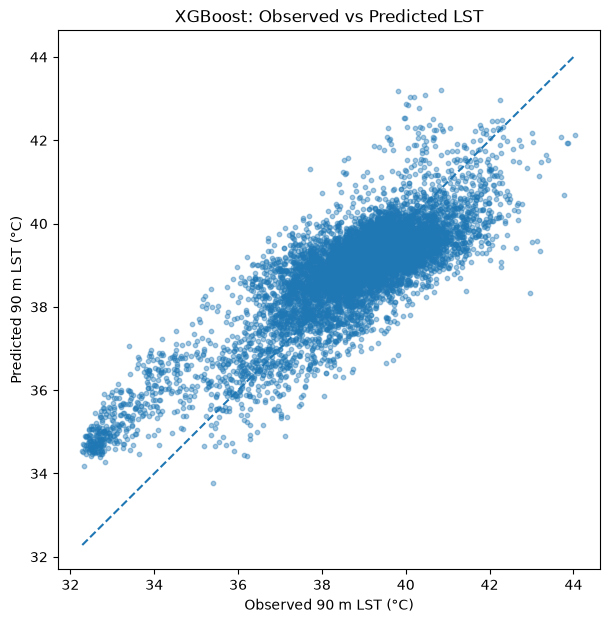

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_5\xgb_observed_vs_predicted.png


In [33]:
from pathlib import Path
import matplotlib.pyplot as plt
PROJECT_DIR = Path(r"D:\Projects\GeoAI-LST-Downscaling")
FIGURES_DIR = PROJECT_DIR / "figures"/ "lucknow"/ "notebook_5"
xgb_scatter_path = FIGURES_DIR / "xgb_observed_vs_predicted.png"

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_test_pred_xgb,
    s=10,
    alpha=0.4
)

min_val = min(
    y_test.min(),
    y_test_pred_xgb.min()
)

max_val = max(
    y_test.max(),
    y_test_pred_xgb.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed 90 m LST (°C)")
plt.ylabel("Predicted 90 m LST (°C)")
plt.title("XGBoost: Observed vs Predicted LST")

plt.savefig(
    xgb_scatter_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", xgb_scatter_path)

In [25]:
residuals_xgb = y_test_pred_xgb - y_test

print("Residual mean:", residuals_xgb.mean())
print("Residual std:", residuals_xgb.std())
print("Residual minimum:", residuals_xgb.min())
print("Residual maximum:", residuals_xgb.max())

Residual mean: 0.080262624
Residual std: 0.9662264
Residual minimum: -4.634079
Residual maximum: 3.6679726


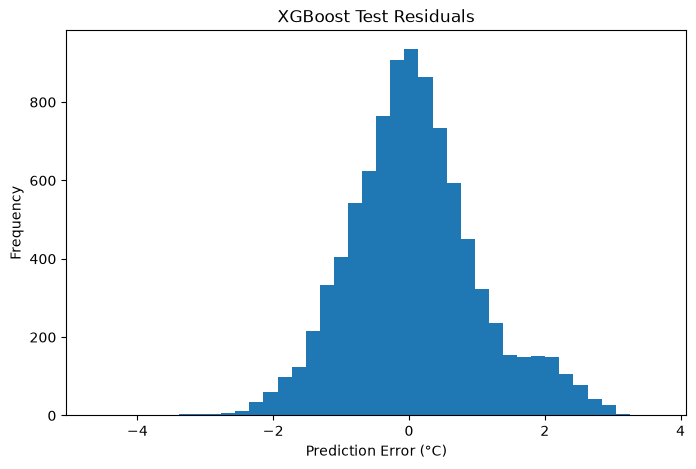

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_5\xgb_residuals.png


In [34]:
xgb_residual_path = FIGURES_DIR / "xgb_residuals.png"

plt.figure(figsize=(8, 5))

plt.hist(
    residuals_xgb,
    bins=40
)

plt.xlabel("Prediction Error (°C)")
plt.ylabel("Frequency")
plt.title("XGBoost Test Residuals")

plt.savefig(
    xgb_residual_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", xgb_residual_path)

In [27]:
print("XGBoost Residual Statistics")
print("-" * 40)

print("Mean:", residuals_xgb.mean())
print("Std :", residuals_xgb.std())
print("Min :", residuals_xgb.min())
print("Max :", residuals_xgb.max())

XGBoost Residual Statistics
----------------------------------------
Mean: 0.080262624
Std : 0.9662264
Min : -4.634079
Max : 3.6679726


### Residual Analysis — Observation

The XGBoost test residuals have a mean of approximately 0.08 °C, indicating only a small overall bias.

The residual standard deviation is approximately 0.97 °C, with errors ranging from approximately −4.63 °C to +3.67 °C.

The residual distribution is concentrated around zero but contains larger errors in both directions, indicating that the model captures the general thermal pattern while still producing substantial errors for some spatial observations.

In [28]:
comparison_xgb = pd.DataFrame({
    "observed": y_test,
    "predicted": y_test_pred_xgb
})

comparison_xgb["residual"] = (
    comparison_xgb["predicted"]
    - comparison_xgb["observed"]
)

comparison_xgb["observed_bin"] = pd.qcut(
    comparison_xgb["observed"],
    q=5,
    duplicates="drop"
)

bin_summary_xgb = comparison_xgb.groupby(
    "observed_bin",
    observed=True
).agg(
    observed_mean=("observed", "mean"),
    predicted_mean=("predicted", "mean"),
    mae=("residual", lambda x: np.mean(np.abs(x))),
    count=("residual", "size")
)

print(bin_summary_xgb)

                              observed_mean  predicted_mean       mae  count
observed_bin                                                                
(32.282000000000004, 37.814]      36.172283       37.257637  1.236349   1829
(37.814, 38.79]                   38.370266       38.728573  0.631299   1829
(38.79, 39.349]                   39.083233       39.143166  0.393874   1829
(39.349, 40.003]                  39.649368       39.406250  0.461673   1827
(40.003, 44.048]                  40.711414       39.851898  0.981620   1829


### Temperature-Range Observation

Prediction performance varies across the observed LST range.

The XGBoost model overpredicts cooler observations and underpredicts hotter observations. The coolest temperature group has an MAE of approximately 1.24 °C, while the hottest group has an MAE of approximately 0.98 °C.

The lowest error occurs in the middle temperature range, with an MAE of approximately 0.39 °C.

This indicates a regression-to-the-mean effect similar to the Random Forest baseline. The XGBoost model therefore does not eliminate the difficulty of reproducing thermal extremes under the current spatial validation setup.

In [29]:
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(xgb_importance)

  feature  importance
2   swir2    0.496821
4    ndbi    0.130450
0   green    0.118758
3    ndvi    0.107341
1   swir1    0.097327
5   mndwi    0.049302


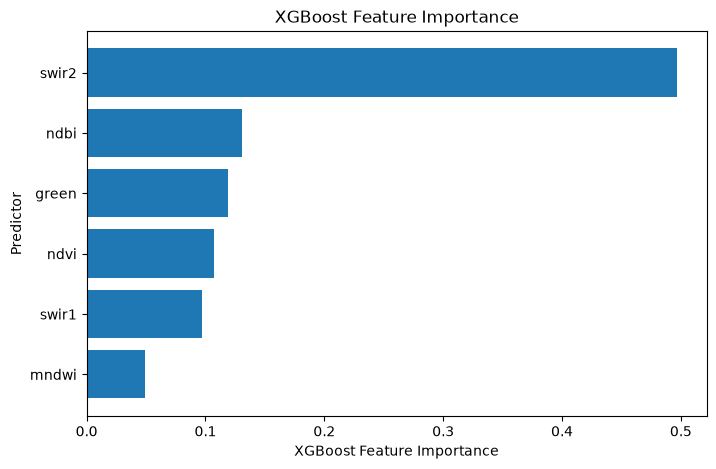

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_5\xgb_feature_importance.png


In [35]:
xgb_importance_path = FIGURES_DIR / "xgb_feature_importance.png"

plt.figure(figsize=(8, 5))

plt.barh(
    xgb_importance["feature"],
    xgb_importance["importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Predictor")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.savefig(
    xgb_importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", xgb_importance_path)

### Feature Importance — Observation

SWIR2 has the highest built-in XGBoost feature importance (0.497), followed by NDBI (0.130), Green (0.119), NDVI (0.107), SWIR1 (0.097), and MNDWI (0.049).

These values indicate how the XGBoost model uses the predictors for its tree-based splits, but they should not be interpreted as direct physical contributions to LST.

Because predictor variables can be correlated, a more robust interpretation of predictor influence will be performed later using SHAP analysis.

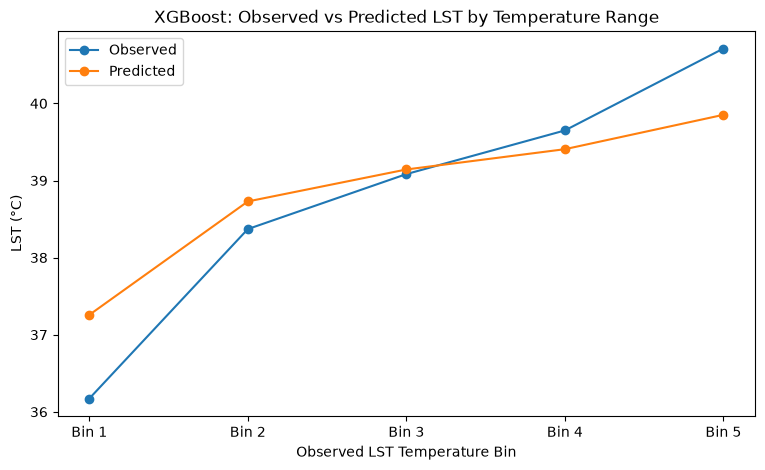

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(len(bin_summary_xgb)),
    bin_summary_xgb["observed_mean"],
    marker="o",
    label="Observed"
)

plt.plot(
    range(len(bin_summary_xgb)),
    bin_summary_xgb["predicted_mean"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Observed LST Temperature Bin")
plt.ylabel("LST (°C)")
plt.title("XGBoost: Observed vs Predicted LST by Temperature Range")

plt.xticks(
    range(len(bin_summary_xgb)),
    [
        f"Bin {i+1}"
        for i in range(len(bin_summary_xgb))
    ]
)

plt.legend()

plt.savefig(
    FIGURES_DIR / "xgb_temperature_bins.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 30 m XGBoost LST Prediction

The trained XGBoost model is applied to the original 30 m predictor rasters to generate a spatially detailed 30 m LST product.

The six original 30 m predictors are passed through the trained model using the same feature order used during training.

The resulting predictions are stored as a 30 m raster and saved as a GeoTIFF while preserving the spatial reference and grid of the input predictors.

In [37]:
fine_predictors = {}

for name, path in predictor_paths.items():

    with rasterio.open(path) as src:
        fine_predictors[name] = src.read(1).astype(np.float32)

        if name == "green":
            fine_profile = src.profile.copy()
            fine_transform = src.transform
            fine_crs = src.crs
            fine_shape = src.shape

        print(
            f"{name}:",
            fine_predictors[name].shape
        )

green: (703, 762)
swir1: (703, 762)
swir2: (703, 762)
ndvi: (703, 762)
ndbi: (703, 762)
mndwi: (703, 762)


In [38]:
fine_common_mask = np.ones(
    fine_shape,
    dtype=bool
)

for name in feature_names:

    data = fine_predictors[name]

    fine_common_mask &= np.isfinite(data)

    if name in ["green", "swir1", "swir2"]:
        fine_common_mask &= data != 0

print(
    "Valid 30 m pixels:",
    fine_common_mask.sum()
)

Valid 30 m pixels: 314853


In [39]:
rows_fine, cols_fine = np.where(
    fine_common_mask
)

X_fine = np.column_stack([
    fine_predictors[name][fine_common_mask]
    for name in feature_names
])

print("X_fine shape:", X_fine.shape)

X_fine shape: (314853, 6)


In [40]:
xgb_30m_pred = np.full(
    fine_shape,
    np.nan,
    dtype=np.float32
)

xgb_30m_pred[fine_common_mask] = (
    xgb_model.predict(X_fine)
    .astype(np.float32)
)

print("XGBoost 30 m LST")
print("----------------------------")
print("Min :", np.nanmin(xgb_30m_pred))
print("Max :", np.nanmax(xgb_30m_pred))
print("Mean:", np.nanmean(xgb_30m_pred))
print("Std :", np.nanstd(xgb_30m_pred))

XGBoost 30 m LST
----------------------------
Min : 33.60115
Max : 44.467197
Mean: 39.210476
Std : 1.3262928


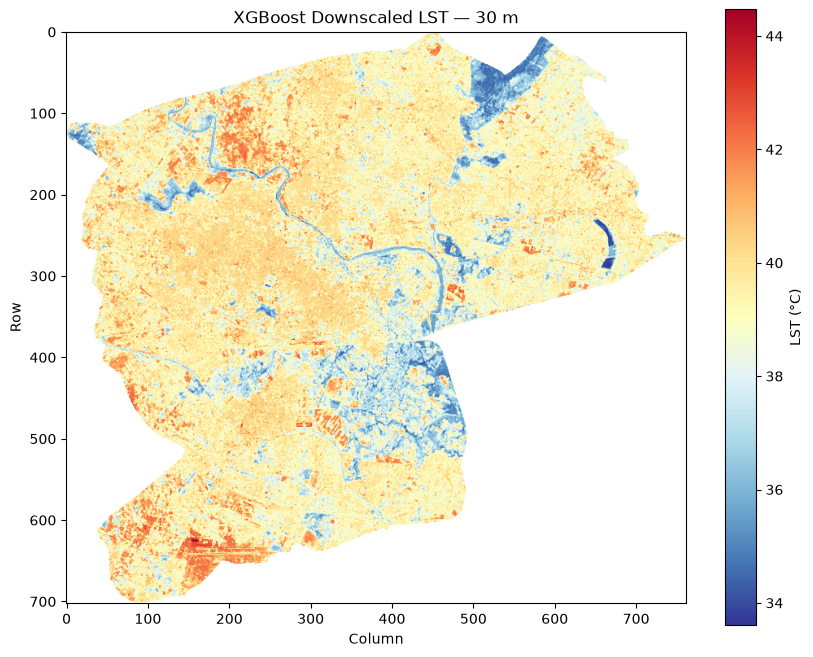

In [42]:
plt.figure(figsize=(10, 8))

plt.imshow(
    xgb_30m_pred,
    cmap="RdYlBu_r"
)

plt.colorbar(
    label="LST (°C)"
)

plt.title(
    "XGBoost Downscaled LST — 30 m"
)

plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    FIGURES_DIR / "xgb_lst_30m.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
XGB_OUTPUT_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "lucknow"
    / "downscaled"
)

XGB_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [44]:
xgb_30m_output = (
    XGB_OUTPUT_DIR
    / "xgb_lst_30m_lucknow.tif"
)

In [45]:
profile = fine_profile.copy()

profile.update(
    dtype="float32",
    count=1,
    nodata=-9999.0,
    compress="lzw"
)

output_data = np.where(
    np.isfinite(xgb_30m_pred),
    xgb_30m_pred,
    -9999.0
).astype(np.float32)

with rasterio.open(
    xgb_30m_output,
    "w",
    **profile
) as dst:

    dst.write(
        output_data,
        1
    )

print("Saved:", xgb_30m_output)

Saved: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\downscaled\xgb_lst_30m_lucknow.tif


### 30 m → 90 m Consistency Evaluation

To evaluate whether the generated 30 m XGBoost product remains consistent with the original coarse-resolution thermal field, the 30 m predictions are aggregated back to the 90 m grid using 3 × 3 pixel means.

The reconstructed 90 m XGBoost LST is then compared with the original 90 m LST.

This is a consistency assessment of the generated downscaled product and is not an independent validation dataset. The spatial test metrics remain the primary measure of model generalization.

In [46]:
xgb_90m_from_30m = aggregate_30m_to_90m(
    xgb_30m_pred,
    nodata=None
)

print("XGBoost reconstructed 90 m shape:",
      xgb_90m_from_30m.shape)

print(
    "Minimum:",
    np.nanmin(xgb_90m_from_30m)
)

print(
    "Maximum:",
    np.nanmax(xgb_90m_from_30m)
)

print(
    "Mean:",
    np.nanmean(xgb_90m_from_30m)
)

print(
    "Std:",
    np.nanstd(xgb_90m_from_30m)
)

XGBoost reconstructed 90 m shape: (234, 254)
Minimum: 33.72141
Maximum: 44.264534
Mean: 39.207214
Std: 1.162542


In [47]:
xgb_consistency_mask = (
    np.isfinite(xgb_90m_from_30m)
    & np.isfinite(lst_90m)
    & (lst_90m != -9999)
)

original_90m_xgb = lst_90m[xgb_consistency_mask]

reconstructed_90m_xgb = (
    xgb_90m_from_30m[xgb_consistency_mask]
)

print(
    "Valid comparison pixels:",
    len(original_90m_xgb)
)

Valid comparison pixels: 35383


In [48]:
xgb_consistency_mae = mean_absolute_error(
    original_90m_xgb,
    reconstructed_90m_xgb
)

xgb_consistency_rmse = np.sqrt(
    mean_squared_error(
        original_90m_xgb,
        reconstructed_90m_xgb
    )
)

xgb_consistency_r2 = r2_score(
    original_90m_xgb,
    reconstructed_90m_xgb
)

print("XGBoost 30 m → 90 m Consistency")
print("-" * 45)

print(
    f"MAE  : {xgb_consistency_mae:.3f} °C"
)

print(
    f"RMSE : {xgb_consistency_rmse:.3f} °C"
)

print(
    f"R²   : {xgb_consistency_r2:.3f}"
)

XGBoost 30 m → 90 m Consistency
---------------------------------------------
MAE  : 0.643 °C
RMSE : 0.836 °C
R²   : 0.685


### 30 m → 90 m Consistency

| Metric | Result |
|---|---:|
| MAE | 0.643 °C |
| RMSE | 0.836 °C |
| R² | 0.685 |

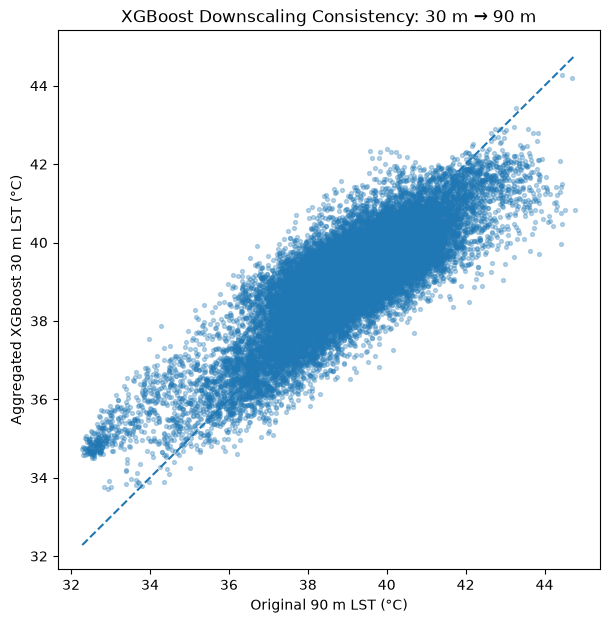

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_5\xgb_consistency_30m.png


In [49]:
xgb_consistency_png = (
    FIGURES_DIR / "xgb_consistency_30m.png"
)

plt.figure(figsize=(7, 7))

plt.scatter(
    original_90m_xgb,
    reconstructed_90m_xgb,
    s=8,
    alpha=0.3
)

min_val = min(
    original_90m_xgb.min(),
    reconstructed_90m_xgb.min()
)

max_val = max(
    original_90m_xgb.max(),
    reconstructed_90m_xgb.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel(
    "Original 90 m LST (°C)"
)

plt.ylabel(
    "Aggregated XGBoost 30 m LST (°C)"
)

plt.title(
    "XGBoost Downscaling Consistency: 30 m → 90 m"
)

plt.savefig(
    xgb_consistency_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", xgb_consistency_png)

### Observation

The reconstructed 90 m XGBoost LST achieves an MAE of 0.643 °C, RMSE of 0.836 °C, and R² of 0.685 when compared with the original 90 m LST.

The result indicates that the 30 m XGBoost product retains a strong correspondence with the original coarse-resolution thermal field after aggregation.

However, these values should not be directly interpreted as independent test performance because the 30 m product originates from the same modelling framework used to generate the predictions.

In [50]:
with rasterio.open(xgb_30m_output) as src:

    saved_xgb = src.read(1)

    print("XGBoost 30 m GeoTIFF")
    print("-" * 40)

    print("Shape:", src.shape)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Dtype:", src.dtypes[0])
    print("NoData:", src.nodata)

    valid = saved_xgb[
        saved_xgb != src.nodata
    ]

    print("\nValue statistics")

    print("Min :", valid.min())
    print("Max :", valid.max())
    print("Mean:", valid.mean())
    print("Std :", valid.std())

XGBoost 30 m GeoTIFF
----------------------------------------
Shape: (703, 762)
CRS: EPSG:32644
Resolution: (30.0, 30.0)
Dtype: float32
NoData: -9999.0

Value statistics
Min : 33.60115
Max : 44.467197
Mean: 39.210472
Std : 1.3262928


In [51]:
with rasterio.open(xgb_30m_output, "r+") as dst:

    dst.update_tags(
        MODEL="XGBoost",
        PRODUCT="30 m Downscaled LST",
        TARGET="90 m LST",
        PREDICTORS="green, swir1, swir2, ndvi, ndbi, mndwi",
        VALIDATION="Spatial block validation",
        TEST_MAE_C="0.741",
        TEST_RMSE_C="0.970",
        TEST_R2="0.683",
        CONSISTENCY_MAE_C="0.643",
        CONSISTENCY_RMSE_C="0.836",
        CONSISTENCY_R2="0.685"
    )

print("XGBoost GeoTIFF metadata updated.")

XGBoost GeoTIFF metadata updated.


### GeoTIFF Validation — Observation

The saved XGBoost 30 m LST GeoTIFF was successfully validated against the expected spatial properties.

The raster has dimensions of 703 × 762 pixels, a spatial resolution of 30 m, and CRS EPSG:32644. The data are stored as float32 values with −9999 used as the NoData value.

The statistics of the saved raster match the generated XGBoost 30 m prediction array, confirming that the downscaled product was written correctly without altering the predicted values.

## Summary and Key Observations

The XGBoost model was implemented using the same six remote-sensing predictors, 90 m target LST, spatial blocks, and train-test partition used for the Random Forest baseline.

### XGBoost Results

| Metric | Training | Spatial Test |
|---|---:|---:|
| MAE (°C) | 0.557 | 0.741 |
| RMSE (°C) | 0.720 | 0.970 |
| R² | 0.726 | 0.683 |

### Key Observations

1. The baseline XGBoost model achieves a spatial test MAE of 0.741 °C, RMSE of 0.970 °C, and R² of 0.683.

2. The baseline XGBoost model performs almost identically to the Random Forest on spatially withheld test regions.

3. XGBoost also shows regression toward the mean, with overprediction of cooler observations and underprediction of hotter observations.

4. SWIR2 has the highest XGBoost feature importance, followed by NDBI, Green, NDVI, SWIR1, and MNDWI. These built-in feature importance values are treated as diagnostic rather than direct measures of physical contribution.

5. A 30 m XGBoost LST product was generated from the original 30 m predictor rasters and saved as a GeoTIFF.

6. The 30 m XGBoost product was aggregated back to 90 m to evaluate consistency with the original coarse-resolution LST.

7. The spatial test metrics remain the primary measure of model generalization. The 30 m → 90 m consistency assessment is used to evaluate the behavior of the generated downscaled product rather than as an independent validation result.

8. The 30 m → 90 m consistency assessment achieved an MAE of 0.643 °C, RMSE of 0.836 °C, and R² of 0.685, indicating that the generated 30 m XGBoost product retains substantial consistency with the original coarse-resolution thermal field.


The XGBoost results will be compared with the TsHARP and Random Forest approaches in the next notebook.

### 30 m → 90 m Consistency

| Metric | Result |
|---|---:|
| MAE | 0.643 °C |
| RMSE | 0.836 °C |
| R² | 0.685 |